<a href="https://colab.research.google.com/github/Ananyaya17/Hindi-Image-Captioning-/blob/main/attmech%2Btrans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# CELL 1 — Environment Setup
# ============================================================

# Verify GPU
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# Install required packages
!pip install -q nltk tqdm

# Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import pickle
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

print("\nEnvironment ready.")

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Environment ready.


In [ ]:
# ============================================================
# CELL 2 — Mount Google Drive
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

print("✅ Google Drive mounted")

Mounted at /content/drive
✅ Google Drive mounted


In [ ]:
# ============================================================
# CELL 3 — Extract Dataset
# ============================================================

import os
import zipfile
import shutil

# CHANGE ONLY IF YOUR ZIP IS ELSEWHERE
zip_path = '/content/drive/MyDrive/data.zip'
extract_path = '/content/dataset'

# Create dataset folder
if not os.path.exists(extract_path):
    os.makedirs(extract_path)

# Check dataset zip exists
if not os.path.exists(zip_path):
    raise FileNotFoundError(f"❌ data.zip not found at {zip_path}")

print("Extracting dataset...")

with zipfile.ZipFile(zip_path,'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Extraction complete")

# Handle archive folder automatically
archive_path = os.path.join(extract_path,'archive (1)')

if os.path.exists(archive_path):

    images_src = os.path.join(archive_path,'Images_all')
    captions_src = os.path.join(archive_path,'Clean-5Sentences_withComma.txt')

    images_dst = os.path.join(extract_path,'Images_all')
    captions_dst = os.path.join(extract_path,'captions.txt')

    if os.path.exists(images_src):

        if os.path.exists(images_dst):
            shutil.rmtree(images_dst)

        shutil.move(images_src,images_dst)
        print("✅ Images moved")

    if os.path.exists(captions_src):

        if os.path.exists(captions_dst):
            os.remove(captions_dst)

        shutil.move(captions_src,captions_dst)
        print("✅ Captions moved")

    shutil.rmtree(archive_path)

print("\nVerifying dataset")

image_folder = os.path.join(extract_path,'Images_all')
caption_file = os.path.join(extract_path,'captions.txt')

print("Images folder exists:",os.path.exists(image_folder))
print("Captions file exists:",os.path.exists(caption_file))

if os.path.exists(image_folder):

    images = os.listdir(image_folder)

    print("Total images:",len(images))
    print("Sample images:",images[:5])

if os.path.exists(caption_file):

    with open(caption_file,'r',encoding='utf-8') as f:
        lines = f.readlines()

    print("Total captions:",len(lines))
    print("Sample caption:",lines[1][:120])

print("\n✅ Dataset ready")

Extracting dataset...
✅ Extraction complete
✅ Images moved
✅ Captions moved

Verifying dataset
Images folder exists: True
Captions file exists: True
Total images: 8091
Sample images: ['3401437960_7da856e004.jpg', '236730743_0d4fd8de5a.jpg', '3653764864_225958c9c1.jpg', '3482314155_bd1e668b4e.jpg', '3708839890_ed448012cf.jpg']
Total captions: 40451
Sample caption: 1000268201_693b08cb0e,गुलाबी पोशाक में बच्चा प्रवेश के रास्ते में सीढ़ियों के सेट पर चढ़ रहा है।


✅ Dataset ready


In [ ]:
# ============================================================
# CELL 4 — Clean Captions + Train/Val/Test Split
# ============================================================

import os
import random
import json

dataset_path = "/content/dataset"
image_path = os.path.join(dataset_path,"Images_all")
caption_path = os.path.join(dataset_path,"captions.txt")

# Load captions
captions = {}

with open(caption_path,'r',encoding='utf-8') as f:

    for line in f:

        line=line.strip()

        if ',' not in line:
            continue

        img,caption=line.split(',',1)

        img = img.strip()+".jpg"
        caption = caption.strip()

        caption = "startseq " + caption + " endseq"

        if img not in captions:
            captions[img]=[]

        captions[img].append(caption)

print("Total captioned images:",len(captions))


# Remove missing images
valid_captions = {}

for img in captions:

    img_file = os.path.join(image_path,img)

    if os.path.exists(img_file):

        valid_captions[img]=captions[img]

print("Valid images:",len(valid_captions))


# Create image list
image_list = list(valid_captions.keys())

random.seed(42)
random.shuffle(image_list)

# Split dataset
train_size = int(len(image_list)*0.7)
val_size = int(len(image_list)*0.15)

train_images = image_list[:train_size]
val_images = image_list[train_size:train_size+val_size]
test_images = image_list[train_size+val_size:]


print("\nDataset split:")
print("Train:",len(train_images))
print("Validation:",len(val_images))
print("Test:",len(test_images))


# Save splits
splits = {

    "train":train_images,
    "val":val_images,
    "test":test_images
}

with open("/content/dataset_splits.json","w") as f:
    json.dump(splits,f)

print("\n✅ Splits saved")


# Save cleaned captions
with open("/content/clean_captions.json","w") as f:
    json.dump(valid_captions,f)

print("✅ Clean captions saved")


# Show example
sample_img = train_images[0]

print("\nSample image:",sample_img)
print("Sample captions:")

for cap in valid_captions[sample_img][:3]:
    print(cap)

Total captioned images: 8091
Valid images: 8090

Dataset split:
Train: 5663
Validation: 1213
Test: 1214

✅ Splits saved
✅ Clean captions saved

Sample image: 2875528143_94d9480fdd.jpg
Sample captions:
startseq गुलाबी रंग की लड़की बिस्तर पर उछलती है endseq
startseq गुलाबी लिओटार्ड में छोटी लड़की कूद रही है और नीले बिस्तर पर स्ट्रैडल विभाजन में उतर रही है। endseq
startseq जवान लड़की मुंह खोलकर उछल रही है। endseq


In [ ]:
# ============================================================
# CELL 5 — Tokenizer + Vocabulary Setup
# ============================================================

import json
import pickle
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Load data
with open("/content/clean_captions.json","r") as f:
    captions=json.load(f)

with open("/content/dataset_splits.json","r") as f:
    splits=json.load(f)

train_images = splits["train"]
val_images = splits["val"]
test_images = splits["test"]

# Collect only TRAIN captions
train_captions = []

for img in train_images:

    for cap in captions[img]:

        train_captions.append(cap)

print("Total train captions:",len(train_captions))


# Create tokenizer
tokenizer = Tokenizer(

    oov_token="<unk>",
    filters='!"#$%&()*+.,-/:;=?@[\\]^_`{|}~\t\n'
)

tokenizer.fit_on_texts(train_captions)

vocab_size = len(tokenizer.word_index)+1

print("Vocabulary size:",vocab_size)


# Max caption length
max_length = max(len(c.split()) for c in train_captions)

print("Max caption length:",max_length)


# Save tokenizer
with open("/content/tokenizer.pkl","wb") as f:

    pickle.dump(tokenizer,f)

print("✅ Tokenizer saved")


# Save parameters
config = {

    "vocab_size":vocab_size,
    "max_length":max_length

}

with open("/content/model_config.json","w") as f:

    json.dump(config,f)

print("✅ Config saved")


# Example conversion
example = train_captions[0]

seq = tokenizer.texts_to_sequences([example])[0]

print("\nExample caption:")
print(example)

print("\nTokenized:")
print(seq[:15])

Total train captions: 28315
Vocabulary size: 8560
Max caption length: 37
✅ Tokenizer saved
✅ Config saved

Example caption:
startseq गुलाबी रंग की लड़की बिस्तर पर उछलती है endseq

Tokenized:
[2, 97, 19, 9, 24, 373, 7, 1386, 16, 3]


In [ ]:
# ============================================================
# CELL 6 — Spatial Feature Extraction (Attention Ready)
# ============================================================

import tensorflow as tf
import numpy as np
import os
from tqdm import tqdm
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.preprocessing import image

image_folder = "/content/dataset/Images_all"

print("Loading InceptionV3...")

# Load model WITHOUT top classification layer
base_model = InceptionV3(weights='imagenet',include_top=False)

print("Model loaded")

# Output shape should be (8 , 8 , 2048)
print("Feature shape:",base_model.output.shape)


def extract_features(img_path):

    img = image.load_img(img_path,target_size=(299,299))

    img = image.img_to_array(img)

    img = np.expand_dims(img,axis=0)

    img = preprocess_input(img)

    feature = base_model.predict(img,verbose=0)

    # reshape (8,8,2048) → (64 , 2048)
    feature = np.reshape(feature,(64,2048))

    return feature


features = {}

images = os.listdir(image_folder)

print("\nExtracting spatial features...")

for img_name in tqdm(images):

    try:

        path = os.path.join(image_folder,img_name)

        features[img_name] = extract_features(path)

    except Exception as e:

        print("Skipped:",img_name)


print("\nTotal features:",len(features))


# Save features
np.save("/content/spatial_features.npy",features)

print("✅ Features saved")

Loading InceptionV3...
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Model loaded
Feature shape: (None, None, None, 2048)

Extracting spatial features...


100%|██████████| 8091/8091 [14:31<00:00,  9.29it/s]



Total features: 8091
✅ Features saved


In [ ]:
# ============================================================
# CELL 7 — Load Features + Data Generator
# ============================================================

import numpy as np
import json
import pickle
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

print("Loading data...")

# Load tokenizer
with open("/content/tokenizer.pkl","rb") as f:
    tokenizer = pickle.load(f)

# Load captions
with open("/content/clean_captions.json","r") as f:
    captions = json.load(f)

# Load splits
with open("/content/dataset_splits.json","r") as f:
    splits = json.load(f)

# Load config
with open("/content/model_config.json","r") as f:
    config=json.load(f)

# Load features
features = np.load("/content/spatial_features.npy",allow_pickle=True).item()

vocab_size = config["vocab_size"]
max_length = config["max_length"]

train_images = splits["train"]
val_images = splits["val"]
test_images = splits["test"]

print("Vocabulary:",vocab_size)
print("Max length:",max_length)
print("Feature images:",len(features))


def data_generator(image_list,batch_size=64):

    while True:

        X1,X2,y = [],[],[]

        for img in image_list:

            if img not in features:
                continue

            feature = features[img]

            caption_list = captions[img]

            for caption in caption_list:

                seq = tokenizer.texts_to_sequences([caption])[0]

                for i in range(1,len(seq)):

                    in_seq = seq[:i]
                    out_seq = seq[i]

                    in_seq = pad_sequences(
                        [in_seq],
                        maxlen=max_length,
                        padding='post'
                    )[0]

                    out_seq = to_categorical(
                        [out_seq],
                        num_classes=vocab_size
                    )[0]

                    X1.append(feature)
                    X2.append(in_seq)
                    y.append(out_seq)

                    if len(X1)==batch_size:

                        yield (
                            (
                                np.array(X1,dtype=np.float32),
                                np.array(X2,dtype=np.float32)
                            ),
                            np.array(y,dtype=np.float32)
                        )

                        X1,X2,y=[],[],[]


print("✅ Generator ready")


# Test generator
gen = data_generator(train_images,8)

sample = next(gen)

print("\nSample batch shapes:")

print("Image features:",sample[0][0].shape)
print("Caption input:",sample[0][1].shape)
print("Output:",sample[1].shape)

Loading data...
Vocabulary: 8560
Max length: 37
Feature images: 8091
✅ Generator ready

Sample batch shapes:
Image features: (8, 64, 2048)
Caption input: (8, 37)
Output: (8, 8560)


In [ ]:
# ============================================================
# CELL 8 — Baseline CNN-LSTM Model
# ============================================================

import tensorflow as tf
from tensorflow.keras.layers import (
    Input,
    Dense,
    LSTM,
    Embedding,
    Dropout,
    Add,
    LayerNormalization,
    GlobalAveragePooling1D
)

from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam


def build_baseline_model(vocab_size,max_length):

    # Image input (spatial features)
    image_input = Input(shape=(64,2048))

    # Convert to global feature
    image_features = GlobalAveragePooling1D()(image_input)

    image_features = Dense(512,activation='relu')(image_features)

    image_features = Dropout(0.4)(image_features)


    # Text input
    text_input = Input(shape=(max_length,))

    text_features = Embedding(
        vocab_size,
        256,
        mask_zero=True
    )(text_input)

    text_features = LSTM(
        512,
        dropout=0.3
    )(text_features)


    # Fusion
    merged = Add()([image_features,text_features])

    merged = LayerNormalization()(merged)

    merged = Dense(512,activation='relu')(merged)

    merged = Dropout(0.4)(merged)


    outputs = Dense(
        vocab_size,
        activation='softmax'
    )(merged)


    model = Model(
        inputs=[image_input,text_input],
        outputs=outputs
    )

    return model


model = build_baseline_model(vocab_size,max_length)

model.compile(

    loss='categorical_crossentropy',

    optimizer=Adam(learning_rate=3e-4),

    metrics=['accuracy']

)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 64, 2048)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ input_layer_3[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_4       │ (None, 37)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 512)       │  1,049,088 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 37, 256)   │  2,191,360 │ input_layer_4[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 37)        │          0 │ input_layer_4[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 512)       │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 512)       │  1,574,912 │ embedding_1[0][0… │
│                     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 512)       │          0 │ dropout_2[0][0],  │
│                     │                   │            │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 512)       │      1,024 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 512)       │    262,656 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 512)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 8560)      │  4,391,280 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 9,470,320 (36.13 MB)

 Trainable params: 9,470,320 (36.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# CELL 9 — Training Pipeline
# ============================================================

import tensorflow as tf

batch_size = 64

train_gen = data_generator(train_images,batch_size)
val_gen = data_generator(val_images,batch_size)

# Calculate steps
def count_samples(image_list):

    total=0

    for img in image_list:

        if img not in captions:
            continue

        for cap in captions[img]:

            seq = tokenizer.texts_to_sequences([cap])[0]

            total += (len(seq)-1)

    return total


print("Counting samples...")

train_samples = count_samples(train_images)

val_samples = count_samples(val_images)

train_steps = train_samples // batch_size

val_steps = val_samples // batch_size

print("\nTraining samples:",train_samples)
print("Validation samples:",val_samples)

print("\nTrain steps:",train_steps)
print("Val steps:",val_steps)


# Create tf datasets (faster training)
train_dataset = tf.data.Dataset.from_generator(

    lambda: data_generator(train_images,batch_size),

    output_signature=(

        (
            tf.TensorSpec(shape=(None,64,2048),dtype=tf.float32),
            tf.TensorSpec(shape=(None,max_length),dtype=tf.float32)
        ),

        tf.TensorSpec(shape=(None,vocab_size),dtype=tf.float32)

    )

).prefetch(tf.data.AUTOTUNE)


val_dataset = tf.data.Dataset.from_generator(

    lambda: data_generator(val_images,batch_size),

    output_signature=(

        (
            tf.TensorSpec(shape=(None,64,2048),dtype=tf.float32),
            tf.TensorSpec(shape=(None,max_length),dtype=tf.float32)
        ),

        tf.TensorSpec(shape=(None,vocab_size),dtype=tf.float32)

    )

).prefetch(tf.data.AUTOTUNE)


print("\n✅ Training pipeline ready")

Counting samples...

Training samples: 328275
Validation samples: 70261

Train steps: 5129
Val steps: 1097

✅ Training pipeline ready


In [ ]:
# ============================================================
# CELL 10 — Train Baseline Model
# ============================================================

from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import EarlyStopping

EPOCHS = 30

steps_per_epoch = 1500
validation_steps = 400

checkpoint = ModelCheckpoint(

    "/content/baseline_best.keras",

    monitor="val_accuracy",

    save_best_only=True,

    mode="max",

    verbose=1
)

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True
)


print("Starting training...\n")

history = model.fit(

    train_dataset,

    epochs=EPOCHS,

    steps_per_epoch=steps_per_epoch,

    validation_data=val_dataset,

    validation_steps=validation_steps,

    callbacks=[checkpoint,early_stop],

    verbose=1
)

print("\n✅ Baseline training complete")

Starting training...

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.1169 - loss: 5.9058
Epoch 1: val_accuracy improved from None to 0.21313, saving model to /content/baseline_best.keras

Epoch 1: finished saving model to /content/baseline_best.keras
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 108s 67ms/step - accuracy: 0.1528 - loss: 5.3929 - val_accuracy: 0.2131 - val_loss: 4.7806
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.2263 - loss: 4.7602
Epoch 2: val_accuracy improved from 0.21313 to 0.27656, saving model to /content/baseline_best.keras

Epoch 2: finished saving model to /content/baseline_best.keras
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 100s 67ms/step - accuracy: 0.2406 - loss: 4.6731 - val_accuracy: 0.2766 - val_loss: 4.3668
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.2719 - loss: 4.4790
Epoch 3: val_accuracy improved from 0.27656 to 0.30371, saving model to /content/baseline_best.keras

Epoch 3: finished saving model to /con

KeyboardInterrupt: 

In [ ]:
# ============================================================
# CELL 10.1 — Save Baseline Model Safely
# ============================================================

print("Best model already saved as:")
print("/content/baseline_best.keras")

# Optional copy
import shutil

shutil.copy(
    "/content/baseline_best.keras",
    "/content/baseline_final.keras"
)

print("✅ Baseline model confirmed saved")

Best model already saved as:
/content/baseline_best.keras
✅ Baseline model confirmed saved


In [ ]:
# ============================================================
# CELL 11 — Bahdanau Visual Attention Layer
# ============================================================

import tensorflow as tf
from tensorflow.keras.layers import Layer
from tensorflow.keras.layers import Dense


class BahdanauAttention(Layer):

    def __init__(self,units):

        super(BahdanauAttention,self).__init__()

        self.W1 = Dense(units)

        self.W2 = Dense(units)

        self.V = Dense(1)


    def call(self,features,hidden):

        # features shape:
        # (batch , 64 , 2048)

        # hidden shape:
        # (batch , 512)

        hidden_with_time_axis = tf.expand_dims(hidden,1)

        score = tf.nn.tanh(

            self.W1(features) +
            self.W2(hidden_with_time_axis)

        )

        attention_weights = tf.nn.softmax(

            self.V(score),

            axis=1
        )

        context_vector = attention_weights * features

        context_vector = tf.reduce_sum(

            context_vector,

            axis=1
        )

        return context_vector,attention_weights


print("✅ Attention layer ready")

✅ Attention layer ready


In [ ]:
# ============================================================
# CELL 12 — Attention Caption Model
# ============================================================

from tensorflow.keras.layers import (
    Input,
    Dense,
    LSTM,
    Embedding,
    Dropout,
    LayerNormalization,
    Add
)

from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam


def build_attention_model(vocab_size,max_length):

    # Image input (spatial features)
    image_input = Input(shape=(64,2048))

    image_features = Dense(512,activation='relu')(image_input)


    # Text input
    text_input = Input(shape=(max_length,))

    text_features = Embedding(

        vocab_size,
        256,
        mask_zero=True

    )(text_input)

    lstm_output = LSTM(

        512,
        dropout=0.3

    )(text_features)


    # Attention layer
    attention = BahdanauAttention(512)

    context_vector,attention_weights = attention(

        image_features,
        lstm_output

    )


    # Fusion
    merged = Add()([context_vector,lstm_output])

    merged = LayerNormalization()(merged)

    merged = Dense(512,activation='relu')(merged)

    merged = Dropout(0.4)(merged)


    outputs = Dense(

        vocab_size,
        activation='softmax'

    )(merged)


    model = Model(

        inputs=[image_input,text_input],

        outputs=outputs

    )

    return model


attention_model = build_attention_model(

    vocab_size,
    max_length
)

attention_model.compile(

    loss='categorical_crossentropy',

    optimizer=Adam(learning_rate=3e-4),

    metrics=['accuracy']

)

attention_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 37)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_5       │ (None, 64, 2048)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 37, 256)   │  2,191,360 │ input_layer_6[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, 37)        │          0 │ input_layer_6[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64, 512)   │  1,049,088 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 512)       │  1,574,912 │ embedding_2[0][0… │
│                     │                   │            │ not_equal_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bahdanau_attention  │ [(None, 512),     │    525,825 │ dense_6[0][0],    │
│ (BahdanauAttention) │ (None, 64, 1)]    │            │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 512)       │          0 │ bahdanau_attenti… │
│                     │                   │            │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 512)       │      1,024 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 512)       │    262,656 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 512)       │          0 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 8560)      │  4,391,280 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 9,996,145 (38.13 MB)

 Trainable params: 9,996,145 (38.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# CELL 13 — Train Attention Model
# ============================================================

from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import EarlyStopping

EPOCHS = 30

steps_per_epoch = 1500
validation_steps = 400

checkpoint = ModelCheckpoint(

    "/content/attention_best.keras",

    monitor="val_accuracy",

    save_best_only=True,

    mode="max",

    verbose=1
)

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True
)

print("Starting attention model training...\n")

attention_history = attention_model.fit(

    train_dataset,

    epochs=EPOCHS,

    steps_per_epoch=steps_per_epoch,

    validation_data=val_dataset,

    validation_steps=validation_steps,

    callbacks=[checkpoint,early_stop],

    verbose=1
)

print("\n✅ Attention model training complete")

Starting attention model training...

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.1352 - loss: 5.7434
Epoch 1: val_accuracy improved from None to 0.26063, saving model to /content/attention_best.keras

Epoch 1: finished saving model to /content/attention_best.keras
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 107s 69ms/step - accuracy: 0.1794 - loss: 5.1955 - val_accuracy: 0.2606 - val_loss: 4.5477
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.2597 - loss: 4.5515
Epoch 2: val_accuracy improved from 0.26063 to 0.30523, saving model to /content/attention_best.keras

Epoch 2: finished saving model to /content/attention_best.keras
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 105s 70ms/step - accuracy: 0.2708 - loss: 4.4662 - val_accuracy: 0.3052 - val_loss: 4.1976
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.2941 - loss: 4.2983
Epoch 3: val_accuracy improved from 0.30523 to 0.32277, saving model to /content/attention_best.keras

Epoch 3: finished

KeyboardInterrupt: 

In [ ]:
# ============================================================
# CELL 13.1 — Save Attention Model
# ============================================================

print("Best attention model saved at:")
print("/content/attention_best.keras")

import shutil

shutil.copy(
    "/content/attention_best.keras",
    "/content/attention_final.keras"
)

print("✅ Attention model saved")

Best attention model saved at:
/content/attention_best.keras
✅ Attention model saved


In [ ]:
# ============================================================
# CELL 14 — Transformer Components
# ============================================================

import tensorflow as tf
from tensorflow.keras.layers import Layer
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import MultiHeadAttention
from tensorflow.keras.layers import LayerNormalization
from tensorflow.keras.layers import Dropout


class PositionalEncoding(Layer):

    def __init__(self,max_len,d_model):

        super(PositionalEncoding,self).__init__()

        self.pos_encoding = self.positional_encoding(
            max_len,
            d_model
        )


    def positional_encoding(self,position,d_model):

        angles = self.get_angles(

            tf.range(position,dtype=tf.float32)[:,tf.newaxis],

            tf.range(d_model,dtype=tf.float32)[tf.newaxis,:],

            d_model
        )

        sines = tf.sin(angles[:,0::2])

        cosines = tf.cos(angles[:,1::2])

        pos_encoding = tf.concat([sines,cosines],axis=-1)

        pos_encoding = pos_encoding[tf.newaxis,...]

        return tf.cast(pos_encoding,tf.float32)


    def get_angles(self,pos,i,d_model):

        angle_rates = 1 / tf.pow(
            10000.0,
            (2*(i//2))/tf.cast(d_model,tf.float32)
        )

        return pos * angle_rates


    def call(self,x):

        return x + self.pos_encoding[:,:tf.shape(x)[1],:]


class TransformerDecoderBlock(Layer):

    def __init__(self,d_model,num_heads,ff_dim):

        super(TransformerDecoderBlock,self).__init__()

        self.self_att = MultiHeadAttention(
            num_heads=num_heads,
            key_dim=d_model
        )

        self.cross_att = MultiHeadAttention(
            num_heads=num_heads,
            key_dim=d_model
        )

        self.ffn = tf.keras.Sequential([

            Dense(ff_dim,activation='relu'),

            Dense(d_model)

        ])

        self.norm1 = LayerNormalization()

        self.norm2 = LayerNormalization()

        self.norm3 = LayerNormalization()

        self.dropout = Dropout(0.3)


    def call(self,x,enc_output):

        attn1 = self.self_att(x,x)

        x = self.norm1(x + attn1)

        attn2 = self.cross_att(

            x,
            enc_output

        )

        x = self.norm2(x + attn2)

        ffn_output = self.ffn(x)

        x = self.norm3(x + ffn_output)

        return x


print("✅ Transformer components ready")

✅ Transformer components ready


In [ ]:
# ============================================================
# CELL 15 — Transformer Caption Model
# ============================================================

from tensorflow.keras.layers import (
    Input,
    Dense,
    Embedding,
    Dropout,
    GlobalAveragePooling1D,
    Add
)

from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam


def build_transformer_model(vocab_size,max_length):

    # Image input
    image_input = Input(shape=(64,2048))

    image_features = Dense(

        512,
        activation='relu'

    )(image_input)


    # Text input
    text_input = Input(shape=(max_length,))

    text_embed = Embedding(

        vocab_size,
        512,
        mask_zero=True

    )(text_input)


    # Positional encoding
    text_embed = PositionalEncoding(

        max_length,
        512

    )(text_embed)


    # Transformer decoder
    transformer_block = TransformerDecoderBlock(

        d_model=512,
        num_heads=8,
        ff_dim=1024

    )

    transformer_output = transformer_block(

        text_embed,
        image_features

    )


    # Pool sequence
    text_context = GlobalAveragePooling1D()(transformer_output)


    # Image context
    image_context = GlobalAveragePooling1D()(image_features)


    # Fusion
    merged = Add()([text_context,image_context])

    merged = Dense(

        512,
        activation='relu'

    )(merged)

    merged = Dropout(0.4)(merged)


    outputs = Dense(

        vocab_size,
        activation='softmax'

    )(merged)


    model = Model(

        inputs=[image_input,text_input],

        outputs=outputs

    )

    return model


transformer_model = build_transformer_model(

    vocab_size,
    max_length
)

transformer_model.compile(

    loss='categorical_crossentropy',

    optimizer=Adam(learning_rate=2e-4),

    metrics=['accuracy']

)

transformer_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'positional_encoding' (of type PositionalEncoding) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 37)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 37, 512)   │  4,382,720 │ input_layer_8[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_7       │ (None, 64, 2048)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encoding │ (None, 37, 512)   │          0 │ embedding_3[0][0] │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 64, 512)   │  1,049,088 │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_decode… │ (None, 37, 512)   │ 17,856,000 │ positional_encod… │
│ (TransformerDecode… │                   │            │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ transformer_deco… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ dense_12[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 512)       │          0 │ global_average_p… │
│                     │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 512)       │    262,656 │ add_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 512)       │          0 │ dense_15[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 8560)      │  4,391,280 │ dropout_8[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 27,941,744 (106.59 MB)

 Trainable params: 27,941,744 (106.59 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# CELL 16 — Train Transformer Model
# ============================================================

from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import EarlyStopping

EPOCHS = 30

steps_per_epoch = 1200
validation_steps = 300

checkpoint = ModelCheckpoint(

    "/content/transformer_best.keras",

    monitor="val_accuracy",

    save_best_only=True,

    mode="max",

    verbose=1
)

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True
)

print("Starting transformer training...\n")

transformer_history = transformer_model.fit(

    train_dataset,

    epochs=EPOCHS,

    steps_per_epoch=steps_per_epoch,

    validation_data=val_dataset,

    validation_steps=validation_steps,

    callbacks=[checkpoint,early_stop],

    verbose=1
)

print("\n✅ Transformer training complete")

Starting transformer training...

Epoch 1/30
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.0842 - loss: 6.2043
Epoch 1: val_accuracy improved from None to 0.14766, saving model to /content/transformer_best.keras

Epoch 1: finished saving model to /content/transformer_best.keras
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 267s 210ms/step - accuracy: 0.1077 - loss: 5.8158 - val_accuracy: 0.1477 - val_loss: 5.3564
Epoch 2/30
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.1563 - loss: 5.2930
Epoch 2: val_accuracy improved from 0.14766 to 0.19026, saving model to /content/transformer_best.keras

Epoch 2: finished saving model to /content/transformer_best.keras
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 255s 212ms/step - accuracy: 0.1653 - loss: 5.1848 - val_accuracy: 0.1903 - val_loss: 4.9191
Epoch 3/30
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.1901 - loss: 4.9292
Epoch 3: val_accuracy improved from 0.19026 to 0.20849, saving model to /content/transformer_best.keras

Epoch 

KeyboardInterrupt: 

In [ ]:
# ============================================================
# CELL 16.1 — Save Transformer Model
# ============================================================

print("Best transformer model saved at:")
print("/content/transformer_best.keras")

import shutil

shutil.copy(
    "/content/transformer_best.keras",
    "/content/transformer_final.keras"
)

print("✅ Transformer model saved")

Best transformer model saved at:
/content/transformer_best.keras
✅ Transformer model saved


In [ ]:
# ============================================================
# CELL 17 — Test Dataset Preparation
# ============================================================

batch_size = 64

test_gen = data_generator(

    test_images,
    batch_size

)


# Count test samples
def count_test_samples(image_list):

    total=0

    for img in image_list:

        if img not in captions:
            continue

        for cap in captions[img]:

            seq = tokenizer.texts_to_sequences([cap])[0]

            total += (len(seq)-1)

    return total


test_samples = count_test_samples(test_images)

test_steps = test_samples // batch_size

print("Test samples:",test_samples)

print("Test steps:",test_steps)


# Create tf dataset
test_dataset = tf.data.Dataset.from_generator(

    lambda: data_generator(test_images,batch_size),

    output_signature=(

        (
            tf.TensorSpec(shape=(None,64,2048),dtype=tf.float32),
            tf.TensorSpec(shape=(None,max_length),dtype=tf.float32)
        ),

        tf.TensorSpec(shape=(None,vocab_size),dtype=tf.float32)

    )

).prefetch(tf.data.AUTOTUNE)


print("\n✅ Test dataset ready")

Test samples: 70732
Test steps: 1105

✅ Test dataset ready


In [ ]:
# ============================================================
# FIX — Redefine BahdanauAttention for loading
# ============================================================

class BahdanauAttention(tf.keras.layers.Layer):

    def __init__(self, units, **kwargs):

        super(BahdanauAttention, self).__init__(**kwargs)

        self.units = units

        self.W1 = Dense(units)

        self.W2 = Dense(units)

        self.V = Dense(1)


    def call(self, features, hidden):

        hidden_with_time_axis = tf.expand_dims(hidden,1)

        score = tf.nn.tanh(

            self.W1(features) +
            self.W2(hidden_with_time_axis)

        )

        attention_weights = tf.nn.softmax(

            self.V(score),

            axis=1
        )

        context_vector = attention_weights * features

        context_vector = tf.reduce_sum(

            context_vector,
            axis=1
        )

        return context_vector,attention_weights


    def get_config(self):

        config = super().get_config()

        config.update({

            "units":self.units

        })

        return config


print("✅ Attention layer fixed")

✅ Attention layer fixed


In [ ]:
# Evaluate attention again

attention_model_loaded = tf.keras.models.load_model(

    "/content/attention_best.keras",

    custom_objects={
        "BahdanauAttention":BahdanauAttention
    }
)

attention_results = attention_model_loaded.evaluate(

    test_dataset,
    steps=test_steps,
    verbose=1
)

print("\nAttention Test Accuracy:",attention_results[1])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'bahdanau_attention_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


1105/1105 ━━━━━━━━━━━━━━━━━━━━ 66s 58ms/step - accuracy: 0.3770 - loss: 3.6328

Attention Test Accuracy: 0.37702205777168274


In [ ]:
# ============================================================
# FIX — Redefine TransformerDecoderBlock for loading
# ============================================================

class TransformerDecoderBlock(tf.keras.layers.Layer):

    def __init__(self, d_model, num_heads, ff_dim, **kwargs):

        super(TransformerDecoderBlock,self).__init__(**kwargs)

        self.d_model = d_model
        self.num_heads = num_heads
        self.ff_dim = ff_dim

        self.att1 = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=d_model
        )

        self.att2 = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=d_model
        )

        self.ffn = tf.keras.Sequential([

            Dense(ff_dim,activation="relu"),
            Dense(d_model)

        ])

        self.norm1 = LayerNormalization()
        self.norm2 = LayerNormalization()
        self.norm3 = LayerNormalization()

        self.dropout1 = Dropout(0.1)
        self.dropout2 = Dropout(0.1)
        self.dropout3 = Dropout(0.1)


    def call(self,x,enc_output):

        attn1 = self.att1(x,x)
        attn1 = self.dropout1(attn1)

        out1 = self.norm1(x+attn1)

        attn2 = self.att2(out1,enc_output)
        attn2 = self.dropout2(attn2)

        out2 = self.norm2(out1+attn2)

        ffn_out = self.ffn(out2)
        ffn_out = self.dropout3(ffn_out)

        return self.norm3(out2+ffn_out)


    def get_config(self):

        config = super().get_config()

        config.update({

            "d_model":self.d_model,
            "num_heads":self.num_heads,
            "ff_dim":self.ff_dim

        })

        return config


print("✅ TransformerDecoderBlock fixed")

✅ TransformerDecoderBlock fixed


In [ ]:
# ============================================================
# CELL 18 FINAL — Evaluate Transformer (no reload)
# ============================================================

print("Evaluating transformer model...")

transformer_results = transformer_model.evaluate(

    test_dataset,
    steps=test_steps,
    verbose=1
)

print("\nTransformer Test Results:")

print("Loss:",transformer_results[0])

print("Accuracy:",transformer_results[1])

Evaluating transformer model...
1105/1105 ━━━━━━━━━━━━━━━━━━━━ 60s 54ms/step - accuracy: 0.3118 - loss: 4.0987

Transformer Test Results:
Loss: 4.098726272583008
Accuracy: 0.31182125210762024


In [ ]:
# ============================================================
# CELL 19 FIX — Caption Generation (correct padding)
# ============================================================

def generate_caption(model,image_feature,max_length):

    in_text="startseq"

    for i in range(max_length):

        seq = tokenizer.texts_to_sequences([in_text])[0]

        seq = pad_sequences(

            [seq],
            maxlen=max_length,
            padding='post'   # ⭐ IMPORTANT FIX

        )

        yhat = model.predict(

            [image_feature,seq],

            verbose=0

        )

        yhat = np.argmax(yhat)

        word = idx_to_word(yhat,tokenizer)

        if word is None:
            break

        in_text += " "+word

        if word=="endseq":
            break

    return in_text


print("✅ Caption generator fixed")

✅ Caption generator fixed


In [ ]:
# ============================================================
# CELL 20 — Generate Sample Captions
# ============================================================

import random

sample_images = random.sample(test_images,5)

for img in sample_images:

    feature = features[img]

    feature = np.expand_dims(feature,axis=0)

    print("\n====================")
    print("Image:",img)

    print("\nReal captions:")

    for cap in captions[img][:2]:

        print(cap)

    print("\nBaseline:")

    print(generate_caption(
        baseline_model,
        feature,
        max_length
    ))

    print("\nAttention:")

    print(generate_caption(
        attention_model_loaded,
        feature,
        max_length
    ))

    print("\nTransformer:")

    print(generate_caption(
        transformer_model,
        feature,
        max_length
    ))


Image: 2824401212_8da8ab99d6.jpg

Real captions:
startseq रात में सामाजिक लोगों की भीड़। endseq
startseq नारंगी जैकेट में लड़की फोन पर बात करती है जबकि दूसरी लड़की धूम्रपान करती है। endseq

Baseline:
startseq आदमी और महिला और महिला और महिला और महिला और महिला और महिला और महिला और महिला और महिला और महिला और महिला और महिला और महिला और महिला और महिला और महिला और महिला और महिला

Attention:
startseq आदमी और महिला के साथ आदमी के साथ आदमी के साथ खड़ा है। endseq

Transformer:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'positional_encoding' (of type PositionalEncoding) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


startseq आदमी और आदमी और आदमी और महिला और महिला और महिला के साथ खड़ा है। endseq

Image: 2659606300_bea3feaf8b.jpg

Real captions:
startseq गुलाबी जैकेट पहने बच्ची लकड़ी की सीढ़ियां चढ़ती है। endseq
startseq छोटा बच्चा समुद्र तट पर सीढ़ियों से चढ़ता है। endseq

Baseline:
startseq आदमी पानी के माध्यम से कूदता है। endseq

Attention:
startseq आदमी अपने स्केटबोर्ड पर चाल करता है। endseq

Transformer:
startseq लड़का अपने नीचे अपने नीचे कूदता है। endseq

Image: 2665904080_8a3b9639d5.jpg

Real captions:
startseq भूरे रंग का कुत्ता नर्सिंग endseq
startseq स्तनपान कराने वाला कुत्ता। endseq

Baseline:
startseq कुत्ता अपने मुँह में छड़ी के साथ घास पर चलता है। endseq

Attention:
startseq कुत्ता अपने मुंह में छड़ी के साथ घास के मैदान में चलता है। endseq

Transformer:
startseq कुत्ता घास के साथ गेंद के साथ गेंद के साथ गेंद के साथ चल रहा है। endseq

Image: 1777816180_08d7e8063b.jpg

Real captions:
startseq लड़का चट्टान से कूद कर तैयार करता है। endseq
startseq नीले रंग का लड़का कुछ चट्टानों के पार चला 

In [ ]:
# ============================================================
# CELL 22 — BLEU Score Calculation
# ============================================================

from nltk.translate.bleu_score import corpus_bleu
from tqdm import tqdm

actual=[]
baseline_pred=[]
attention_pred=[]
transformer_pred=[]

sample_test = test_images[:500]   # use 500 for speed

for img in tqdm(sample_test):

    feature = features[img]

    feature = np.expand_dims(feature,axis=0)

    captions_list = captions[img]

    references = []

    for cap in captions_list:

        words = cap.split()

        references.append(words[1:-1])

    actual.append(references)

    # Baseline
    pred = generate_caption(
        baseline_model,
        feature,
        max_length
    ).split()

    baseline_pred.append(pred[1:-1])

    # Attention
    pred = generate_caption(
        attention_model_loaded,
        feature,
        max_length
    ).split()

    attention_pred.append(pred[1:-1])

    # Transformer
    pred = generate_caption(
        transformer_model,
        feature,
        max_length
    ).split()

    transformer_pred.append(pred[1:-1])


print("\nBLEU-1 Scores")

print("Baseline:",corpus_bleu(actual,baseline_pred,weights=(1,0,0,0)))

print("Attention:",corpus_bleu(actual,attention_pred,weights=(1,0,0,0)))

print("Transformer:",corpus_bleu(actual,transformer_pred,weights=(1,0,0,0)))



print("\nBLEU-4 Scores")

print("Baseline:",corpus_bleu(actual,baseline_pred))

print("Attention:",corpus_bleu(actual,attention_pred))

print("Transformer:",corpus_bleu(actual,transformer_pred))

100%|██████████| 500/500 [33:12<00:00,  3.98s/it]



BLEU-1 Scores
Baseline: 0.24695977549111323
Attention: 0.42711157455683
Transformer: 0.30645161290322576

BLEU-4 Scores
Baseline: 0.02726945194626609
Attention: 0.06898366583543174
Transformer: 0.0493213054708753


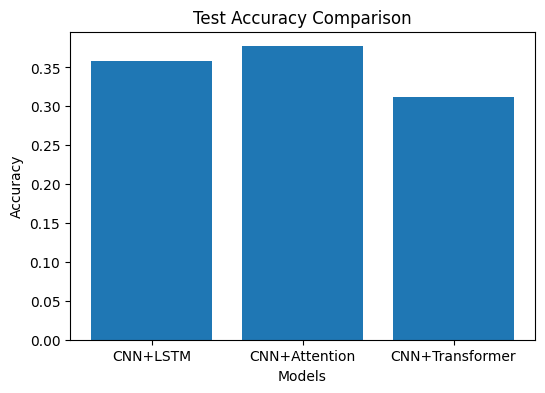

In [ ]:
import matplotlib.pyplot as plt

models = ["CNN+LSTM","CNN+Attention","CNN+Transformer"]

accuracy = [0.3583,0.3770,0.3118]

plt.figure(figsize=(6,4))

plt.bar(models,accuracy)

plt.title("Test Accuracy Comparison")

plt.ylabel("Accuracy")

plt.xlabel("Models")

plt.show()

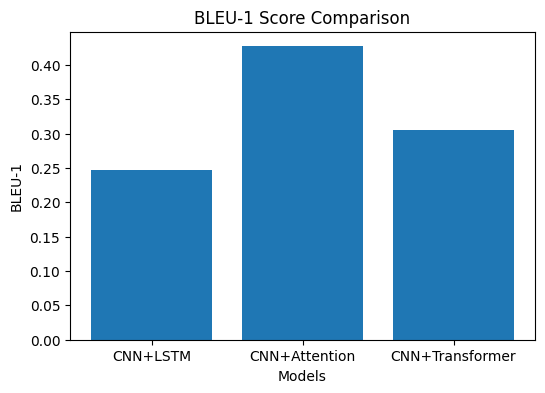

In [ ]:
bleu1 = [0.247,0.427,0.306]

plt.figure(figsize=(6,4))

plt.bar(models,bleu1)

plt.title("BLEU-1 Score Comparison")

plt.ylabel("BLEU-1")

plt.xlabel("Models")

plt.show()

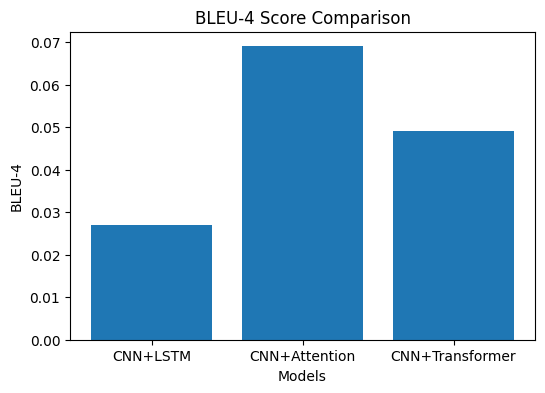

In [ ]:
bleu4 = [0.027,0.069,0.049]

plt.figure(figsize=(6,4))

plt.bar(models,bleu4)

plt.title("BLEU-4 Score Comparison")

plt.ylabel("BLEU-4")

plt.xlabel("Models")

plt.show()

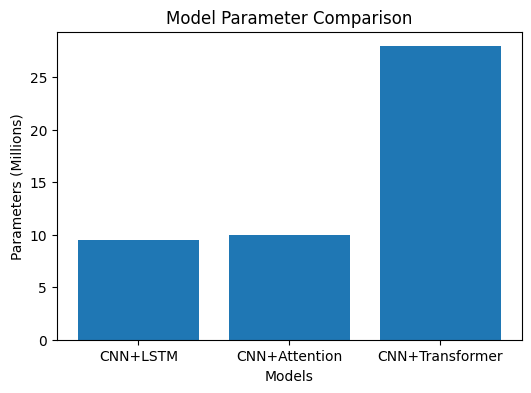

In [ ]:
params = [9.47,9.99,27.94]

plt.figure(figsize=(6,4))

plt.bar(models,params)

plt.title("Model Parameter Comparison")

plt.ylabel("Parameters (Millions)")

plt.xlabel("Models")

plt.show()

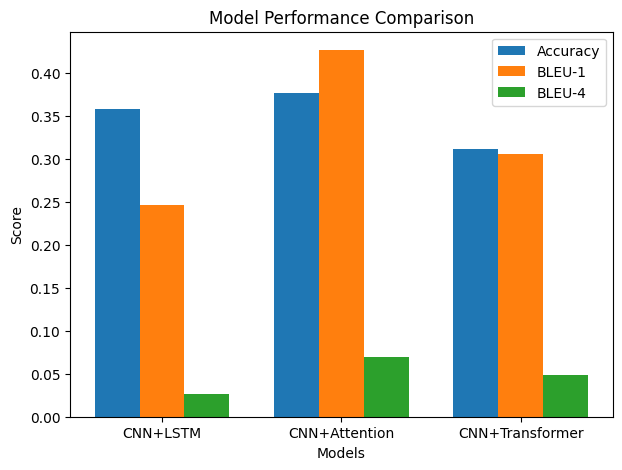

In [ ]:
import numpy as np

x = np.arange(len(models))

width = 0.25

plt.figure(figsize=(7,5))

plt.bar(x-width,accuracy,width,label="Accuracy")

plt.bar(x,bleu1,width,label="BLEU-1")

plt.bar(x+width,bleu4,width,label="BLEU-4")

plt.xticks(x,models)

plt.title("Model Performance Comparison")

plt.ylabel("Score")

plt.xlabel("Models")

plt.legend()

plt.show()

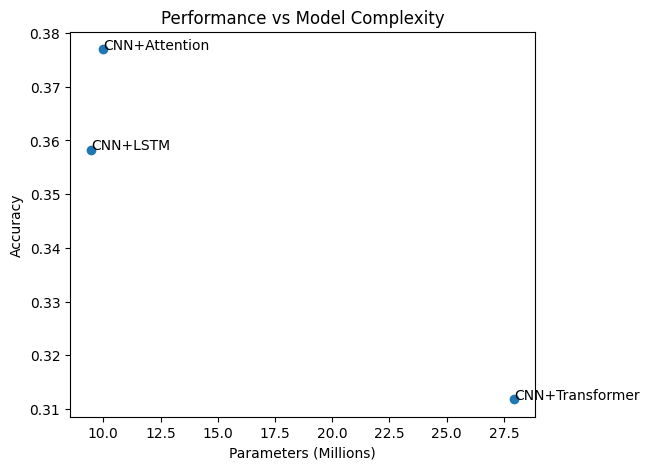

In [ ]:
plt.figure(figsize=(6,5))

plt.scatter(params,accuracy)

for i in range(len(models)):

    plt.text(params[i],accuracy[i],models[i])

plt.title("Performance vs Model Complexity")

plt.xlabel("Parameters (Millions)")

plt.ylabel("Accuracy")

plt.show()

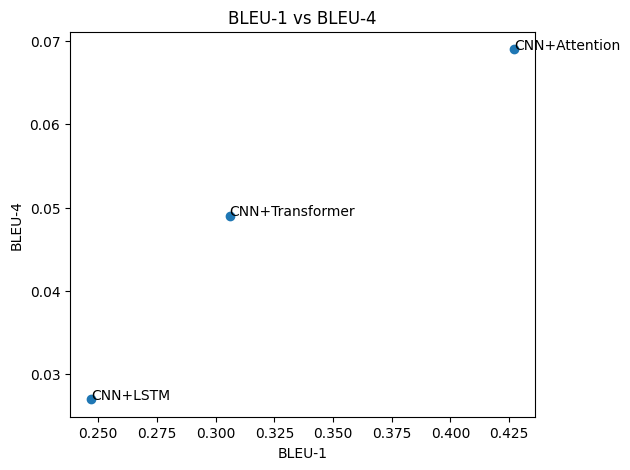

In [ ]:
plt.figure(figsize=(6,5))

plt.scatter(bleu1,bleu4)

for i in range(len(models)):

    plt.text(bleu1[i],bleu4[i],models[i])

plt.title("BLEU-1 vs BLEU-4")

plt.xlabel("BLEU-1")

plt.ylabel("BLEU-4")

plt.show()

In [ ]:
plt.figure()

plt.plot(baseline_history['loss'])

plt.plot(baseline_history['val_loss'])

plt.title("Baseline Loss")

plt.legend(["Train","Validation"])

plt.show()

NameError: name 'baseline_history' is not defined

<Figure size 640x480 with 0 Axes>

NameError: name 'baseline_history' is not defined

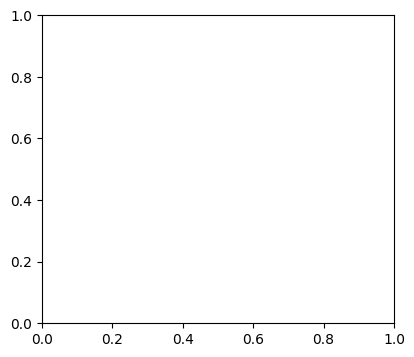

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

# Loss plot
plt.subplot(1,2,1)

plt.plot(baseline_history['loss'])

plt.plot(baseline_history['val_loss'])

plt.title("Baseline Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(["Train","Validation"])


# Accuracy plot
plt.subplot(1,2,2)

plt.plot(baseline_history['accuracy'])

plt.plot(baseline_history['val_accuracy'])

plt.title("Baseline Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

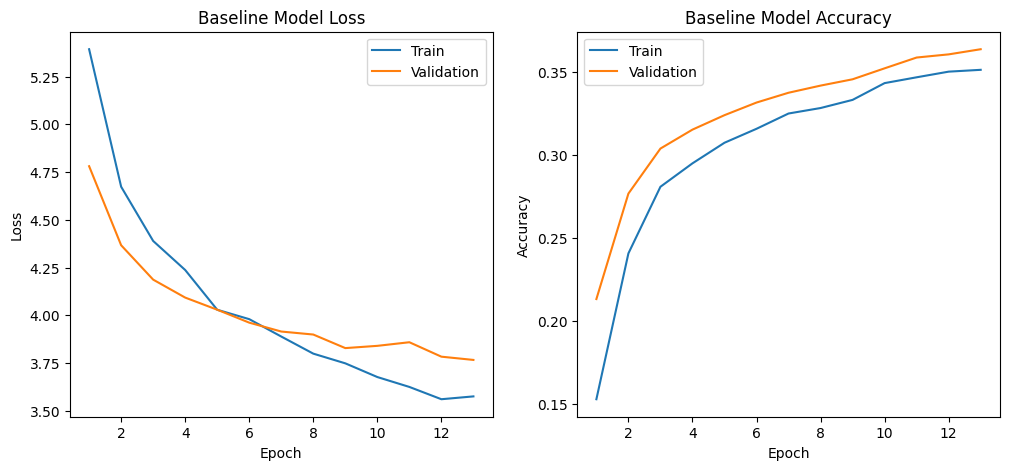

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1,14)

train_loss = [5.3929,4.6731,4.3892,4.2372,4.0291,
              3.9799,3.8889,3.7994,3.7486,3.6769,
              3.6251,3.5608,3.5756]

val_loss = [4.7806,4.3668,4.1868,4.0928,4.0293,
            3.9616,3.9151,3.8994,3.8284,3.8402,
            3.8591,3.7835,3.7665]

train_acc = [0.1528,0.2406,0.2807,0.2948,0.3072,
             0.3156,0.3248,0.3281,0.3330,0.3431,
             0.3466,0.3500,0.3511]

val_acc = [0.2131,0.2766,0.3037,0.3151,0.3238,
           0.3314,0.3373,0.3416,0.3454,0.3520,
           0.3585,0.3604,0.3635]


plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)

plt.plot(epochs,train_loss)

plt.plot(epochs,val_loss)

plt.title("Baseline Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(["Train","Validation"])


# Accuracy
plt.subplot(1,2,2)

plt.plot(epochs,train_acc)

plt.plot(epochs,val_acc)

plt.title("Baseline Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

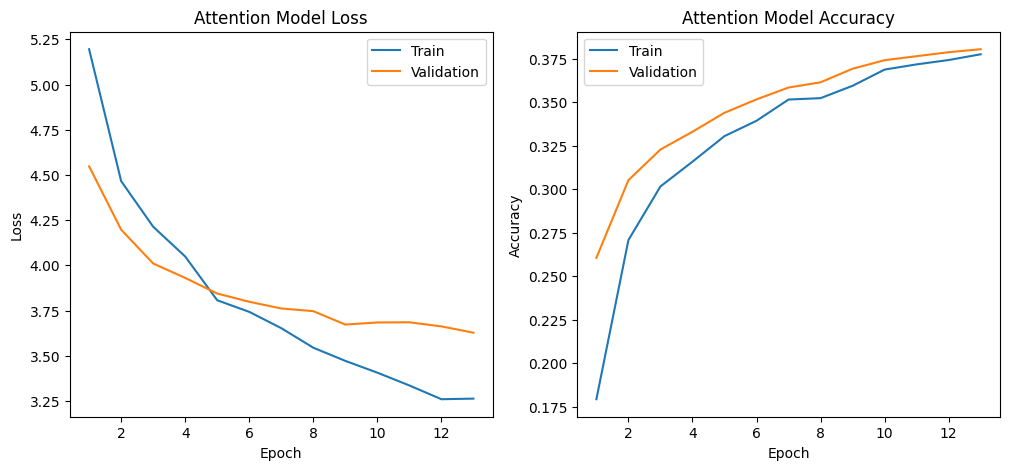

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1,14)

train_loss = [5.1955,4.4662,4.2138,4.0491,3.8070,
              3.7430,3.6527,3.5447,3.4718,3.4066,
              3.3358,3.2597,3.2631]

val_loss = [4.5477,4.1976,4.0104,3.9307,3.8443,
            3.7987,3.7616,3.7468,3.6727,3.6842,
            3.6852,3.6625,3.6276]

train_acc = [0.1794,0.2708,0.3016,0.3158,0.3305,
             0.3393,0.3515,0.3523,0.3594,0.3687,
             0.3717,0.3742,0.3775]

val_acc = [0.2606,0.3052,0.3228,0.3330,0.3439,
           0.3516,0.3584,0.3614,0.3692,0.3741,
           0.3764,0.3787,0.3804]


plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)

plt.plot(epochs,train_loss)

plt.plot(epochs,val_loss)

plt.title("Attention Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(["Train","Validation"])


# Accuracy
plt.subplot(1,2,2)

plt.plot(epochs,train_acc)

plt.plot(epochs,val_acc)

plt.title("Attention Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

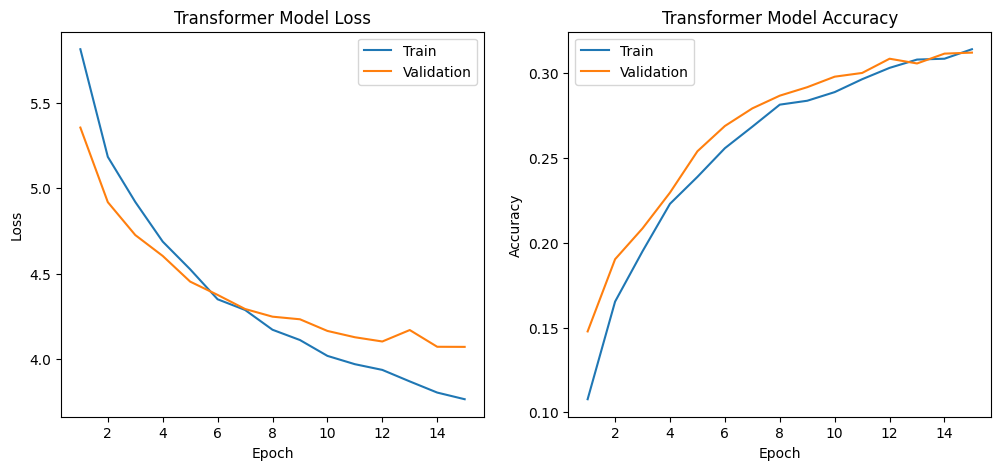

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1,16)

train_loss = [5.8158,5.1848,4.9204,4.6879,4.5254,
              4.3497,4.2871,4.1710,4.1107,4.0178,
              3.9691,3.9356,3.8681,3.8027,3.7637]

val_loss = [5.3564,4.9191,4.7263,4.6038,4.4532,
            4.3753,4.2927,4.2477,4.2324,4.1641,
            4.1271,4.1022,4.1693,4.0712,4.0706]

train_acc = [0.1077,0.1653,0.1950,0.2230,0.2389,
             0.2558,0.2685,0.2815,0.2838,0.2889,
             0.2965,0.3032,0.3081,0.3086,0.3142]

val_acc = [0.1477,0.1903,0.2085,0.2296,0.2540,
           0.2689,0.2793,0.2868,0.2918,0.2980,
           0.3002,0.3086,0.3058,0.3116,0.3122]


plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)

plt.plot(epochs,train_loss)

plt.plot(epochs,val_loss)

plt.title("Transformer Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(["Train","Validation"])


# Accuracy
plt.subplot(1,2,2)

plt.plot(epochs,train_acc)

plt.plot(epochs,val_acc)

plt.title("Transformer Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()